# Phase 0 — Data exploration

Sanity check both external datasets before starting any experiment.

**Goals:**
1. Confirm both datasets load via `experiments.data_loaders`.
2. Cross-reference plant IDs between the voxel set and Jensina's CSVs.
3. Visualize one plant end-to-end: voxel hull, skeleton, and `angles.txt` traits.
4. Inspect trait distributions (per leaf node, per voxel-length variant).
5. Confirm the 10-plant manual ground-truth set (`leafLevelTraits.csv`) is *not* in the voxel set — it's the 2024 panel.

Run with `pip install -e ".[experiments]"` and the two external datasets in place (see `experiments/README.md`).

In [1]:
import sys
from pathlib import Path

# Make the repo root importable when running from the experiment dir.
REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == '01_phyllotaxis' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments import paths, data_loaders as dl

paths.assert_data_present()
print('✓ External datasets present')

✓ External datasets present


## 1. Smoke-test all loaders

Each loader returns a DataFrame or numpy array. Just print shapes for now.

In [2]:
phi_4cm = dl.load_jensina_phi_csv(voxel_len='4cm')
theta_4cm = dl.load_jensina_theta_csv(voxel_len='4cm')
raw_4cm = dl.load_jensina_raw_angles('4cm')
manual = dl.load_jensina_manual()
geno, js_pi = dl.load_jensina_genotypes()
voxel_plants = dl.list_voxel_plants()

print(f'phi (4cm):       {phi_4cm.shape}     unique plants: {phi_4cm["plant_name"].nunique()}')
print(f'theta (4cm):     {theta_4cm.shape}     unique plants: {theta_4cm["plant_name"].nunique()}')
print(f'raw angles 4cm:  {raw_4cm.shape}')
print(f'manual GT:       {manual.shape}      unique plant IDs: {manual["plantID"].nunique()}')
print(f'genotypes:       {geno.shape}')
print(f'JS<->PI map:     {js_pi.shape}     columns: {js_pi.columns.tolist()}')
print(f'voxel plants:    {len(voxel_plants)}')

phi (4cm):       (977, 21)     unique plants: 977
theta (4cm):     (977, 21)     unique plants: 977
raw angles 4cm:  (1092, 71)
manual GT:       (62, 7)      unique plant IDs: 10
genotypes:       (223, 1)
JS<->PI map:     (246, 3)     columns: ['Unnamed: 0', 'JS_ID', 'PI#']
voxel plants:    351


## 2. Cross-reference: which plants overlap across data sources?

The headline number we need is **how many plants have voxels AND CSV trait data**. That's the size of the dataset for any cross-source experiment.

In [3]:
phi_all = dl.load_jensina_phi_csv(voxel_len=None)
theta_all = dl.load_jensina_theta_csv(voxel_len=None)

set_voxel = set(voxel_plants)
set_phi   = set(phi_all['plant_name'].dropna().astype(str))
set_theta = set(theta_all['plant_name'].dropna().astype(str))

print(f'Voxel plants:                  {len(set_voxel):>4}')
print(f'phi CSV plants:                {len(set_phi):>4}')
print(f'theta CSV plants:              {len(set_theta):>4}')
print(f'voxel ∩ phi:                   {len(set_voxel & set_phi):>4}')
print(f'voxel ∩ theta:                 {len(set_voxel & set_theta):>4}')
print(f'voxel ∩ phi ∩ theta:           {len(set_voxel & set_phi & set_theta):>4}')
print()
print(f'voxel only (no CSV trait data): {len(set_voxel - set_phi):>4}')
print(f'CSV only (no voxels in dataset): {len(set_phi - set_voxel):>4}')
print()

# Manual GT: confirm it's the 2024 panel (different ID system: simple integers)
manual_ids = manual['plantID'].astype(str).unique().tolist()
manual_in_voxels = sum(any(mid in vp for vp in set_voxel) for mid in manual_ids)
print(f'Manual GT plant IDs (10 plants from 2024): {manual_ids}')
print(f'  → present in voxel set:   {manual_in_voxels}')
print(f'  → present in phi CSV:     {sum(any(mid in p for p in set_phi) for mid in manual_ids)}')

Voxel plants:                   351
phi CSV plants:                 977
theta CSV plants:               977
voxel ∩ phi:                    330
voxel ∩ theta:                  330
voxel ∩ phi ∩ theta:            330

voxel only (no CSV trait data):   21
CSV only (no voxels in dataset):  647

Manual GT plant IDs (10 plants from 2024): ['187', '188', '189', '190', '191', '192', '193', '194', '195', '196']
  → present in voxel set:   9
  → present in phi CSV:     9


In [4]:
# Build a metadata table for the voxel set: parse plant_id, attach reconstruction errors.
vox_meta = dl.voxel_plant_metadata()
print(f'voxel_plant_metadata: {vox_meta.shape}')
vox_meta.head(3)

voxel_plant_metadata: (351, 7)


,plant_id,plant_num,js_id,img_date,recon_error,skel_error,has_skeleton
0,4-9-18_Schnable_49-281-JS39-65_2018-04-11_12-0...,281.0,JS39-65,2018-04-11,0.918884,0.049892,True
1,4-9-18_Schnable_49-282-js254-408_2018-04-11_12...,282.0,js254-408,2018-04-11,0.898426,0.139493,True
2,4-9-18_Schnable_49-283-js254-408_2018-04-11_12...,283.0,js254-408,2018-04-11,0.894724,0.108818,True


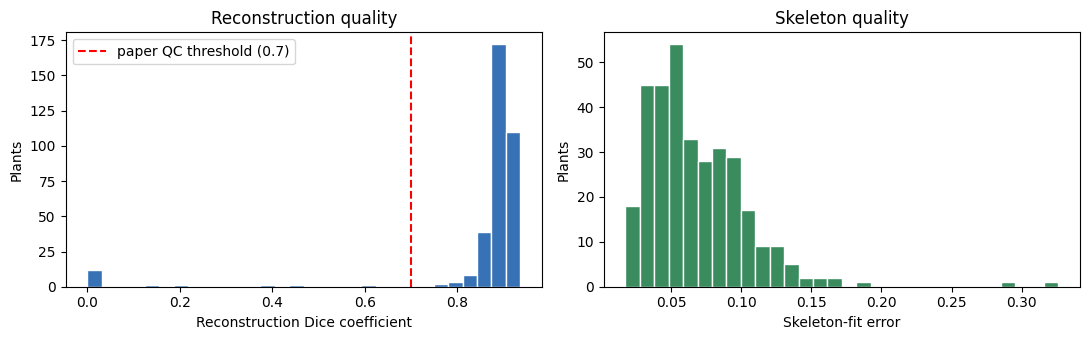

recon_error: mean=0.854, min=0.000, max=0.936
skel_error:  mean=0.068, min=0.018, max=0.326


In [5]:
# Quality control: distribution of reconstruction Dice scores and skeleton errors
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(vox_meta['recon_error'], bins=30, color='#3672b5', edgecolor='white')
axes[0].axvline(0.7, color='red', ls='--', label='paper QC threshold (0.7)')
axes[0].set_xlabel('Reconstruction Dice coefficient'); axes[0].set_ylabel('Plants'); axes[0].set_title('Reconstruction quality')
axes[0].legend()
axes[1].hist(vox_meta['skel_error'], bins=30, color='#3a8c5e', edgecolor='white')
axes[1].set_xlabel('Skeleton-fit error'); axes[1].set_ylabel('Plants'); axes[1].set_title('Skeleton quality')
plt.tight_layout(); plt.show()

print(f'recon_error: mean={vox_meta["recon_error"].mean():.3f}, min={vox_meta["recon_error"].min():.3f}, max={vox_meta["recon_error"].max():.3f}')
print(f'skel_error:  mean={vox_meta["skel_error"].mean():.3f}, min={vox_meta["skel_error"].min():.3f}, max={vox_meta["skel_error"].max():.3f}')

## 3. Empirical trait distributions (Jensina CSVs)

These are the **target distributions** for E9 (distribution match). Look at θ and φ per leaf node, and the deviation from perfectly alternating phyllotaxy Φᵢ = |φᵢ − 180°|.

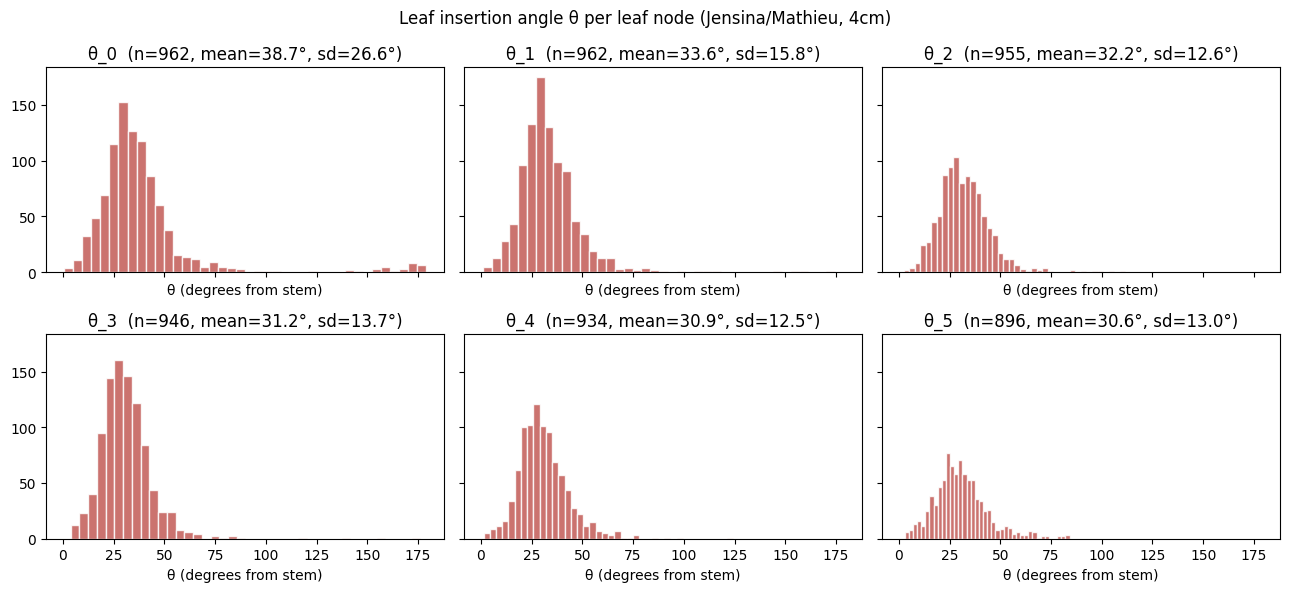

In [6]:
# θ per leaf node (lower 6 leaves)
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    col = f'theta_{i}'
    if col not in theta_4cm.columns:
        continue
    vals = theta_4cm[col].dropna()
    ax.hist(vals, bins=40, color='#c25b56', edgecolor='white', alpha=0.85)
    ax.set_title(f'θ_{i}  (n={len(vals)}, mean={vals.mean():.1f}°, sd={vals.std():.1f}°)')
    ax.set_xlabel('θ (degrees from stem)')
fig.suptitle('Leaf insertion angle θ per leaf node (Jensina/Mathieu, 4cm)')
plt.tight_layout(); plt.show()

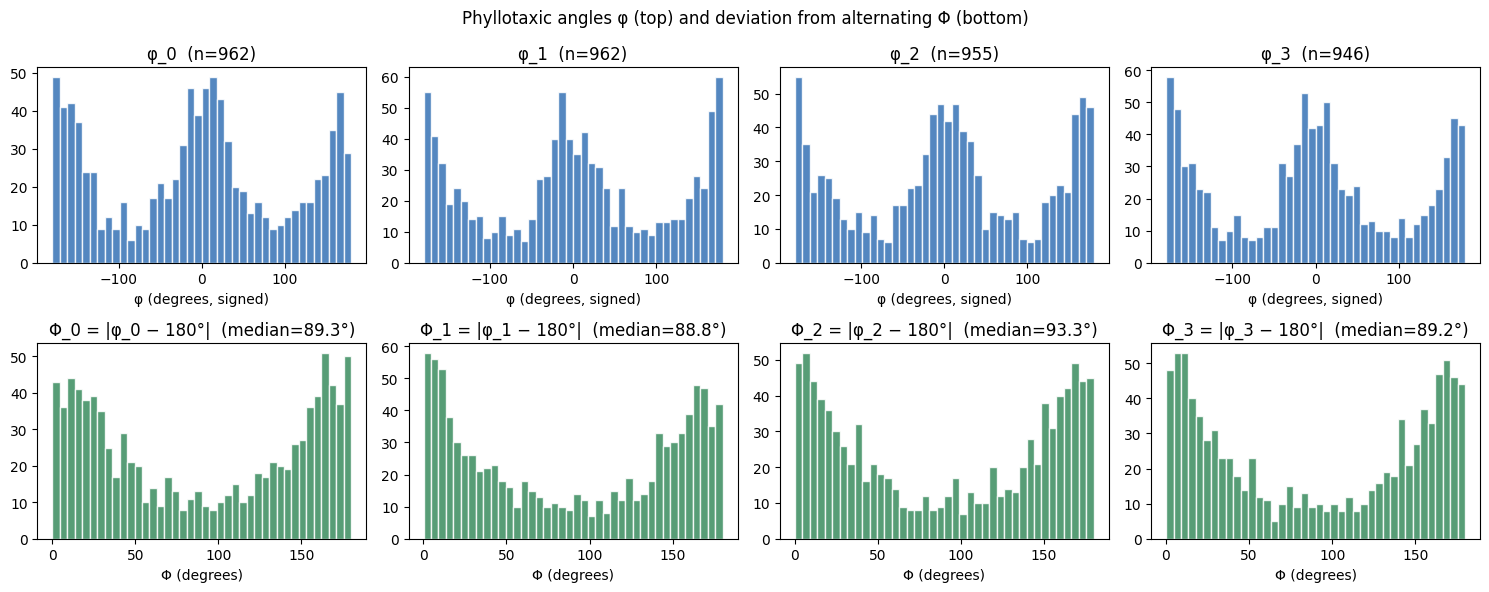

In [7]:
# φ (phyllotaxic angle, signed) and Φ = |φ − 180°| (deviation from alternating) per node
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i in range(4):
    col = f'phi_{i}'
    if col not in phi_4cm.columns:
        continue
    vals = phi_4cm[col].dropna()
    # Top row: raw phyllotaxic angle (already differenced ϕᵢ₊₁ − ϕᵢ)
    axes[0, i].hist(vals, bins=40, color='#3672b5', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'φ_{i}  (n={len(vals)})')
    axes[0, i].set_xlabel('φ (degrees, signed)')
    # Bottom row: deviation from alternating
    Phi = (vals.abs() - 180).abs()  # Φ = |φ − 180°| if φ already in [-180,180]; here vals can be ±, take |·| first
    axes[1, i].hist(Phi, bins=40, color='#3a8c5e', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'Φ_{i} = |φ_{i} − 180°|  (median={Phi.median():.1f}°)')
    axes[1, i].set_xlabel('Φ (degrees)')
fig.suptitle('Phyllotaxic angles φ (top) and deviation from alternating Φ (bottom)')
plt.tight_layout(); plt.show()

### Voxel-length comparison

Jensina computed θ and φ at four different leaf-base distances (4cm, 6cm, 8cm, 12cm) for the PCA fit. Confirm the trait values shift smoothly — useful both as a sanity check and as a built-in robustness knob for E1.

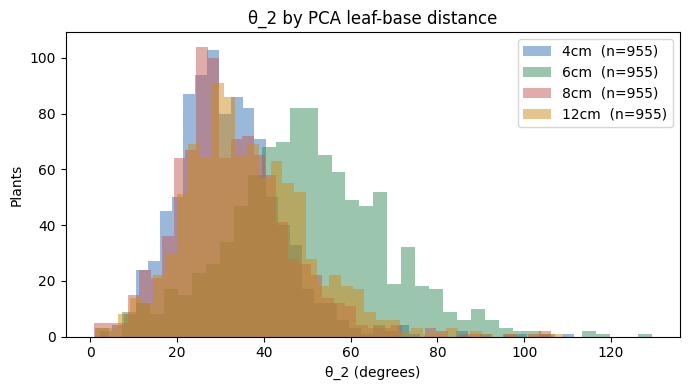

In [8]:
# theta_2 (mid-canopy leaf, well-populated) across the 4 voxel-length variants
fig, ax = plt.subplots(figsize=(7, 4))
for vlen, color in zip(dl.VOXEL_LENGTHS, ['#3672b5', '#3a8c5e', '#c25b56', '#cc8c1c']):
    df = dl.load_jensina_theta_csv(voxel_len=vlen)
    vals = df['theta_2'].dropna()
    ax.hist(vals, bins=40, alpha=0.5, label=f'{vlen}  (n={len(vals)})', color=color)
ax.set_xlabel('θ_2 (degrees)'); ax.set_ylabel('Plants'); ax.set_title('θ_2 by PCA leaf-base distance')
ax.legend()
plt.tight_layout(); plt.show()

## 4. Single-plant deep dive

Pick a representative plant and look at its full reconstruction: voxel point cloud, skeleton overlaid, and the `angles.txt` traits per leaf.

In [9]:
# Pick a plant with median reconstruction quality and several leaves
# (so the plot is interesting and representative)
candidates = vox_meta[(vox_meta['recon_error'] > 0.85) & (vox_meta['recon_error'] < 0.95)].copy()
# Pick one we know has multiple leaves
for plant_id in candidates['plant_id']:
    ang = dl.load_angles_txt(plant_id)
    if 6 <= len(ang) <= 12:
        break
print(f'Showing: {plant_id}')
print(f'  recon_error: {dl.load_reconstruction_error(plant_id):.3f}')
print(f'  skel_error:  {dl.load_skeleton_error(plant_id):.3f}')
print(f'  leaves:      {len(ang)}')
ang

Showing: 4-9-18_Schnable_49-281-JS39-65_2018-04-11_12-09-35_9968800
  recon_error: 0.919
  skel_error:  0.050
  leaves:      9


,leaf_index,height_norm,theta,phi
0,0,-0.357143,35.7473,-170.84700
1,1,-0.325832,27.5290,-24.85740
2,2,-0.306262,29.5886,-173.23600
3,3,-0.274951,18.6445,-18.91320
4,4,-0.239726,17.0514,-167.35200
5,5,-0.239726,13.1306,88.86050
6,6,-0.153620,35.1655,-5.26523
7,7,-0.134051,21.4240,162.19100
8,8,-0.134051,22.1008,-58.91430


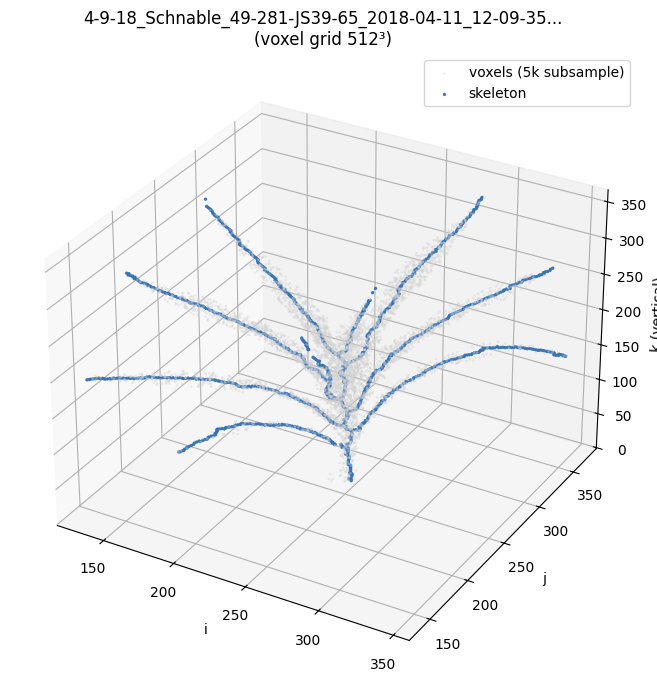

In [10]:
# 3D scatter: voxel reconstruction (subsampled) + skeleton overlaid
vox = dl.load_voxel_grid(plant_id)
sk = dl.load_skeleton(plant_id)

# Subsample voxels for plotting speed
rng = np.random.default_rng(0)
vox_sub = vox[rng.choice(len(vox), size=min(5000, len(vox)), replace=False)]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vox_sub[:, 0], vox_sub[:, 1], vox_sub[:, 2], s=1, c='lightgray', alpha=0.3, label='voxels (5k subsample)')
ax.scatter(sk[:, 0], sk[:, 1], sk[:, 2], s=2, c='#3672b5', alpha=0.9, label='skeleton')
ax.set_xlabel('i'); ax.set_ylabel('j'); ax.set_zlabel('k (vertical)')
ax.set_title(f'{plant_id[:50]}...\n(voxel grid 512³)')
ax.legend()
plt.tight_layout(); plt.show()

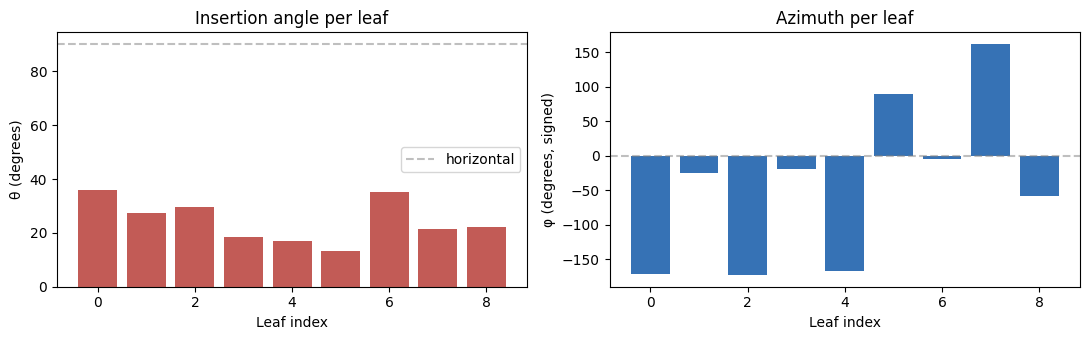

In [11]:
# Per-leaf trait values (gold-standard from the Gaillard pipeline)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(ang['leaf_index'], ang['theta'], color='#c25b56')
axes[0].set_xlabel('Leaf index'); axes[0].set_ylabel('θ (degrees)'); axes[0].set_title('Insertion angle per leaf')
axes[0].axhline(90, color='gray', ls='--', alpha=0.5, label='horizontal')
axes[0].legend()
axes[1].bar(ang['leaf_index'], ang['phi'], color='#3672b5')
axes[1].set_xlabel('Leaf index'); axes[1].set_ylabel('φ (degrees, signed)'); axes[1].set_title('Azimuth per leaf')
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 5. Summary - what this confirms

The local data layout is sufficient for the sorghum validation experiments. The Jensina/Mathieu processed trait tables load cleanly, and the voxel archive contains 351 reconstructed plants, of which 332 have usable skeletons. The key overlap for validation is the set of 330 plants that appear in the voxel archive and in both the phi and theta CSV tables.

The manual ground-truth table should not be treated as a direct validation target for this voxel set. Although the numeric IDs overlap with some table entries, those manual measurements come from a different 2024 panel, so they are useful as format/context checks rather than as paired observations for E1-E5.

The practical conclusion is that E1/E1b/E4/E5 can be run on the sorghum voxel-skeleton cohort, while E6 remains blocked unless a truly paired manual annotation set is produced. The processed CSVs and genotype mapping also provide the bridge needed for the later population-level experiments, especially heritability and distribution matching.